# Разработка A/B-тестирования и анализ результатов¶

- Автор: Сереженко Елена

## 0.1. Цели и задачи проекта

Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Основные задачи:
- рассчитать параметры A/B-теста, который позволит проверить эту гипотезу;
- проанализировать его результаты.

## 0.2. Описание данных

Три таблицы:
- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:
* `user_id` — идентификатор пользователя;
* `session_id` — идентификатор сессии в приложении;
* `session_date` — дата сессии;
* `session_start_ts` — дата и время начала сессии;
* `install_date` — дата установки приложения;
* `session_number` — порядковый номер сессии для конкретного пользователя;
* `registration_flag` — является ли пользователь зарегистрированным;
* `page_counter` — количество просмотренных страниц во время сессии;
* `region` — регион пользователя;
* `device` — тип устройства пользователя;
* `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

## Содержание проекта

* [1. Работа с историческими данными (EDA)](#1.-Работа-с-историческими-данными-(EDA))
    * [1.1. Загрузка исторических данных](#1.1.-Загрузка-исторических-данных)
    * [1.2. Знакомство с данными](#1.2.-Знакомство-с-данными)
    * [1.3. Анализ числа регистраций](#1.3.-Анализ-числа-регистраций)
    * [1.4. Анализ числа просмотренных страниц](#1.4.-Анализ-числа-просмотренных-страниц)
    * [1.5. Доля пользователей, просмотревших более четырёх страниц](#1.5.-Доля-пользователей,-просмотревших-более-четырёх-страниц)
* [2. Подготовка к тесту](#2.-Подготовка-к-тесту)
    * [2.1. Расчёт размера выборки](#2.1.-Расчёт-размера-выборки)
    * [2.2. Расчёт длительности A/B-теста](#2.2.-Расчёт-длительности-A/B-теста)
* [3. Мониторинг А/В-теста](#3.-Мониторинг-А/В-теста)
    * [3.1. Проверка распределения пользователей](#3.1.-Проверка-распределения-пользователей)
    * [3.2. Проверка пересечений пользователей](#3.2.-Проверка-пересечений-пользователей)
    * [3.3. Равномерность разделения пользователей по устройствам](#3.3.-Равномерность-разделения-пользователей-по-устройствам)
    * [3.4. Равномерность распределения пользователей по регионам](#3.4.-Равномерность-распределения-пользователей-по-регионам)
    * [3.5. Вывод после проверки A/B-теста](#3.5.-Вывод-после-проверки-A/B-теста)
* [4. Проверка результатов A/B-теста](#4.-Проверка-результатов-A/B-теста)
    * [4.1. Получение результатов теста и подсчёт основной метрики](#4.1.-Получение-результатов-теста-и-подсчёт-основной-метрики)
    * [4.2. Формулировка нулевой и альтернативной гипотез...](#4.2.-Формулировка-нулевой-и-альтернативной-гипотез.-Определение-целевой,-прокси-и-барьерных-метрик)
    * [4.3. Сравнение доли успешных сессий](#4.3.-Сравнение-доли-успешных-сессий)
    * [4.4. Насколько статистически значимо изменение ключевой метрики](#4.4.-Насколько-статистически-значимо-изменение-ключевой-метрики)
    * [4.5. Вывод по результатам A/B-эксперимента](#4.5.-Вывод-по-результатам-A/B-эксперимента)

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
Импортируем библиотеку `pandas`. 
Дополнительно импортируем библиотеки, необходимые для дальнейшей работы.

Посчитаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
#Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns

In [2]:
#Выгружаем первые 5 строк датафрейма sessions_history
sessions_history=pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [3]:
#Считаем количество сессий, сортируем и выводим первых 10 пользователей 
sessions_user=(sessions_history.groupby('user_id')['session_id'].nunique().reset_index().rename(columns={'session_id':'session_count'}))

sessions_user.sort_values(by='session_count', ascending=False).head(10)

,user_id,session_count
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9
109383,D11541BAC141FB94,9
47956,5BCFE7C4DCC148E9,9
22611,2AF89E9BC4D631A3,9
29354,37E4825C6A22A519,9
53434,66374F4203EFEDA7,9
16936,1FE6E098C8A7E9A3,9
84534,A1E1B4CCA664587C,9


In [4]:
#Находим пользователя с максимальным количеством сессий, выводим таблицу с его данными и изучаем
max_user_id=sessions_user.loc[sessions_user['session_count'].idxmax(),'user_id']
max_user_data=sessions_history[sessions_history['user_id']==max_user_id].sort_values(by='session_start_ts')

max_user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### 1.3. Анализ числа регистраций
Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения.

Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [5]:
#Выведем число уникальных пользователей по дням
date_uniq_users=sessions_history.groupby('session_date')['user_id'].nunique()
date_uniq_users=date_uniq_users.sort_index()

date_uniq_users

session_date
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64

In [6]:
#Выведем число зарегестрированных пользователей по дням
date_regisrt_users=sessions_history.groupby('session_date')['registration_flag'].sum()
date_regisrt_users=date_regisrt_users.sort_index()

date_regisrt_users

session_date
2025-08-11     169
2025-08-12     336
2025-08-13     464
2025-08-14     625
2025-08-15     840
2025-08-16     916
2025-08-17     833
2025-08-18     860
2025-08-19     831
2025-08-20    1008
2025-08-21    1063
2025-08-22    1251
2025-08-23    1253
2025-08-24    1181
2025-08-25    1060
2025-08-26    1050
2025-08-27    1076
2025-08-28    1175
2025-08-29    1174
2025-08-30    1165
2025-08-31    1105
2025-09-01    1028
2025-09-02    1039
2025-09-03    1035
2025-09-04    1007
2025-09-05    1030
2025-09-06    1023
2025-09-07    1069
2025-09-08    1009
2025-09-09     980
2025-09-10    1015
2025-09-11     824
2025-09-12     669
2025-09-13     537
2025-09-14     440
2025-09-15     383
2025-09-16     286
2025-09-17     272
2025-09-18     201
2025-09-19     132
2025-09-20     107
2025-09-21      87
2025-09-22      68
2025-09-23      32
Name: registration_flag, dtype: int64

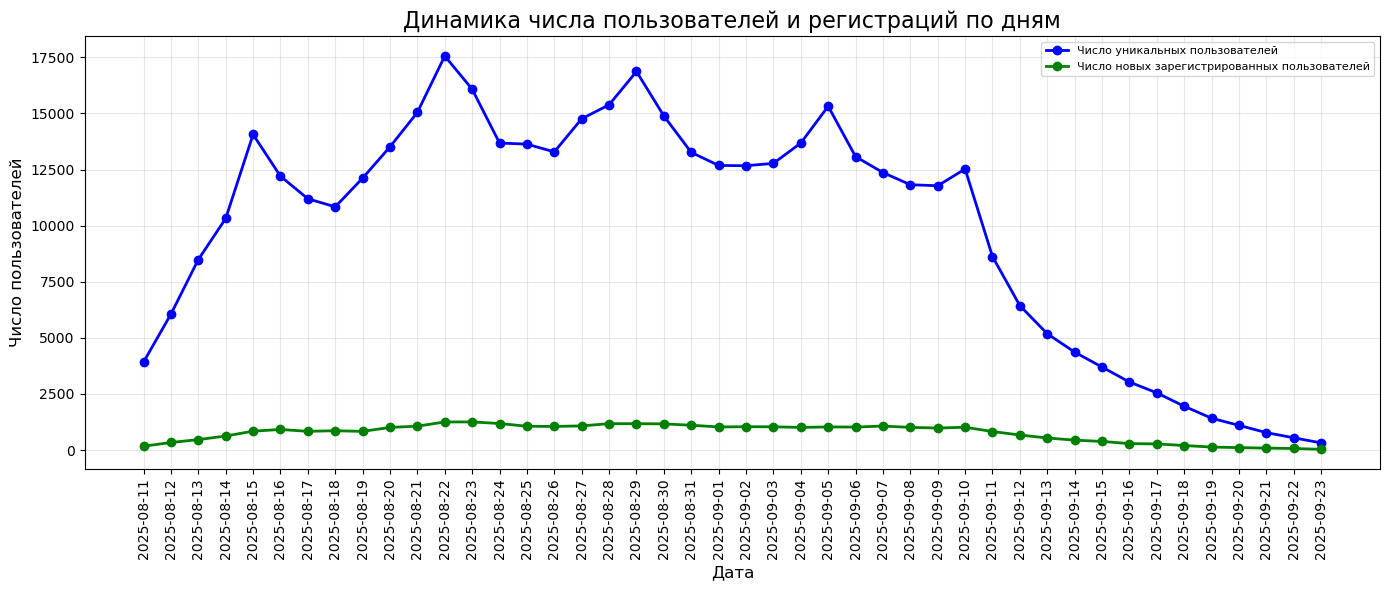

In [7]:
#Построим объединённый график числа уникальных пользователей и числа новых регистраций
plt.figure(figsize=(14, 6))

plt.plot(date_uniq_users.index, date_uniq_users.values, 
         label='Число уникальных пользователей', 
         marker='o', 
         linewidth=2,
         color='blue')

plt.plot(date_regisrt_users.index, date_regisrt_users.values, 
         label='Число новых зарегистрированных пользователей', 
         marker='o', 
         linewidth=2,
         color='green')

plt.title('Динамика числа пользователей и регистраций по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Число пользователей', fontsize=12)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()

В период с августа по сентябрь наблюдалась краткосрочная вспышка пользовательской активности (пик — 22 августа, 17563 пользователя), вероятно, вызванная внешними факторами (маркетинговая кампания, запуск продукта, начало учебного года). Однако этот приток не привёл к устойчивому росту. После пика последовал резкий и продолжительный спад (к 11 сентября — резкое падение с 12526 до 8623 пользователей и дальнейшее снижение).

Конверсия в регистрации осталась критически низкой (500–1500 регистраций в день даже на фоне пикового трафика), что указывает на неспособность продукта удерживать аудиторию и превращать посетителей в активных пользователей.

Нет корреляции между ростом трафика и ростом регистраций - большинство новых пользователей не конвертируются в зарегистрированных.

In [8]:
#Посчитаем долю зарегестрированных
date_ratio_reg=date_regisrt_users/date_uniq_users

date_ratio_reg

session_date
2025-08-11    0.043123
2025-08-12    0.055482
2025-08-13    0.054659
2025-08-14    0.060556
2025-08-15    0.059723
2025-08-16    0.075051
2025-08-17    0.074375
2025-08-18    0.079343
2025-08-19    0.068576
2025-08-20    0.074589
2025-08-21    0.070627
2025-08-22    0.071229
2025-08-23    0.077913
2025-08-24    0.086311
2025-08-25    0.077741
2025-08-26    0.079013
2025-08-27    0.072870
2025-08-28    0.076358
2025-08-29    0.069579
2025-08-30    0.078235
2025-08-31    0.083296
2025-09-01    0.081041
2025-09-02    0.081992
2025-09-03    0.081005
2025-09-04    0.073595
2025-09-05    0.067215
2025-09-06    0.078223
2025-09-07    0.086440
2025-09-08    0.085320
2025-09-09    0.083192
2025-09-10    0.081031
2025-09-11    0.095558
2025-09-12    0.103947
2025-09-13    0.103608
2025-09-14    0.100825
2025-09-15    0.103569
2025-09-16    0.094327
2025-09-17    0.106750
2025-09-18    0.102971
2025-09-19    0.093089
2025-09-20    0.097273
2025-09-21    0.112113
2025-09-22    0.12454

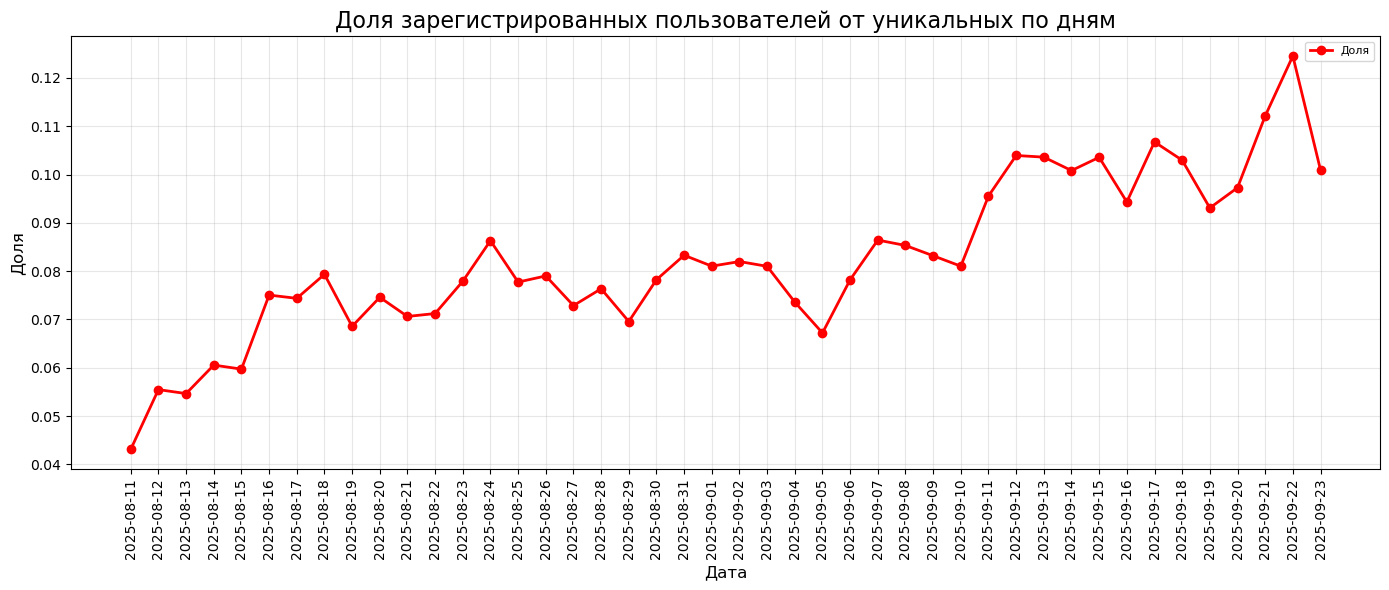

In [9]:
#Построим график
plt.figure(figsize=(14, 6))

plt.plot(date_ratio_reg.index, date_ratio_reg.values, 
         label='Доля', 
         marker='o', 
         linewidth=2,
         color='red')

plt.title('Доля зарегистрированных пользователей от уникальных по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля', fontsize=12)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()

Конверсия из посетителей в зарегистрированных пользователей не растёт даже при пиковом трафике. Несмотря на отдельные эпизоды роста доли регистраций (с 4.3%), общий уровень остаётся низким, а динамика непостоянна.

11 сентября: 9.6% (824/8623) – несмотря на падение активности, доля регистраций увеличивается.

Для устойчивого роста продукта необходимо сфокусироваться на улучшении конверсии и удержании пользователей.

#### 1.4. Анализ числа просмотренных страниц
Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдём количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

Построим столбчатую диаграмму.

In [10]:
#Посчитаем количество просмотров по количеству страниц
view_page=sessions_history.groupby('page_counter')['session_id'].count()

view_page

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

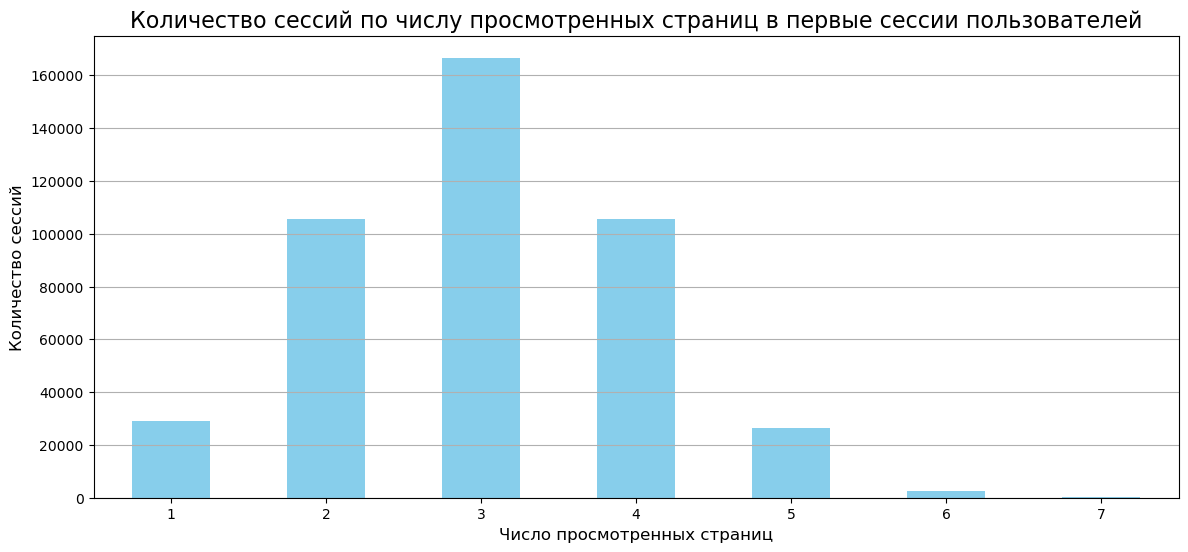

In [11]:
#Построим график
plt.figure(figsize=(14, 6))
ax = view_page.plot(kind='bar', color='skyblue')

plt.title('Количество сессий по числу просмотренных страниц в первые сессии пользователей', fontsize=16)
plt.xlabel('Число просмотренных страниц', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y')

# Добавляем числа на столбцы
#for container in ax.containers:
#    ax.bar_label(container, labels=[f'{val}' for val in container.datavalues],
#                padding=3, color='black', fontsize=10, rotation=0)

plt.show()

Пик активности пользователей приходится на 3‑ю страницу (166690 сессий), что существенно превышает показатели других этапов:
- страницы 2 и 4 имеют близкие значения (105536 и 105569 сессий соответственно);
- страницы 6 и 7 демонстрируют резкое снижение (2589 и 92 сессии).

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

Построим график со средним значением доли успешных сессий от всех первых сессий пользователей.

In [12]:
#Cоздаём дополнительный столбец good_session
sessions_history['good_session']=(sessions_history['page_counter']>=4).astype(int)

sessions_history[['session_id', 'page_counter', 'good_session']].head()

,session_id,page_counter,good_session
0,F9AF61A0C2023832,3,0
1,85003A206CBDAC6F,4,1
2,3677423E49D72DEE,4,1
3,956B45F5915CA225,4,1
4,83BF0DA35F9F1F40,3,0


In [13]:
# Группируем по дням, считаем среднюю долю good_session от всех первых сессий пользователей
daily_good_sessions=sessions_history.groupby(
    pd.to_datetime(sessions_history['session_date'])).agg(
    success_rate=('good_session', 'mean')).reset_index()

daily_good_sessions

,session_date,success_rate
0,2025-08-11,0.312835
1,2025-08-12,0.302015
2,2025-08-13,0.306750
3,2025-08-14,0.316055
4,2025-08-15,0.304941
5,2025-08-16,0.306186
6,2025-08-17,0.317589
7,2025-08-18,0.310545
8,2025-08-19,0.312840
9,2025-08-20,0.306941


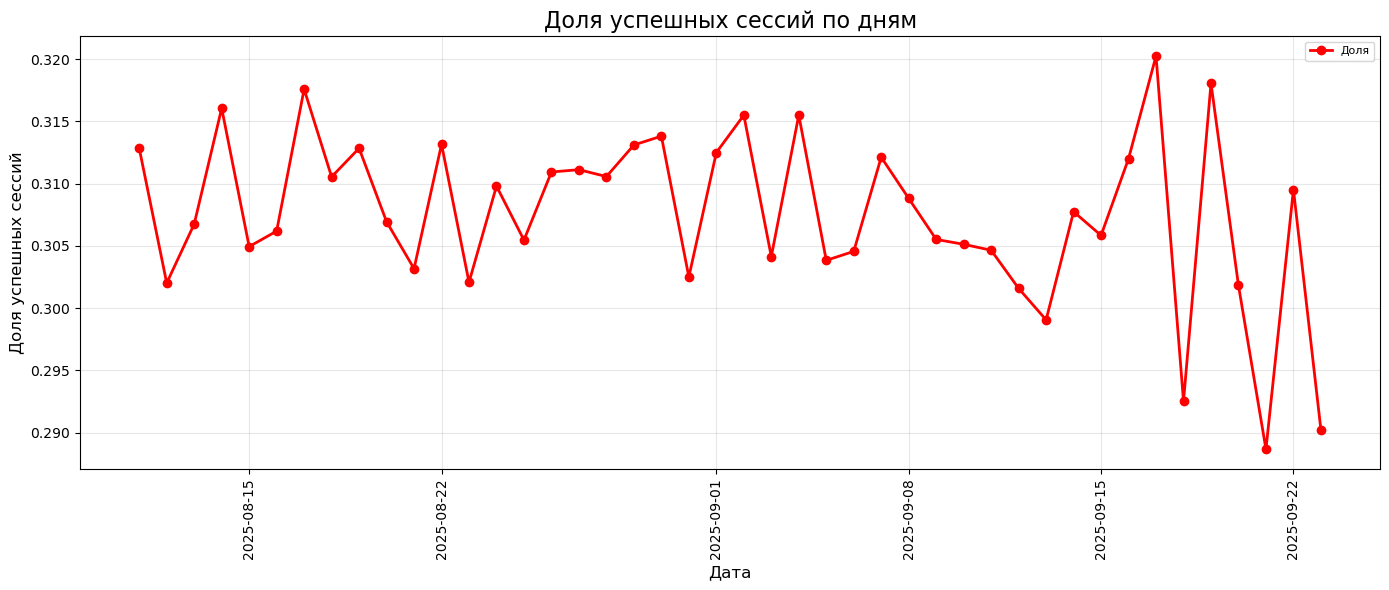

In [14]:
#Построим график
plt.figure(figsize=(14, 6))

plt.plot(daily_good_sessions['session_date'], daily_good_sessions['success_rate'], 
         label='Доля', 
         marker='o', 
         linewidth=2,
         color='red')

# Настройки графика
plt.title('Доля успешных сессий по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных сессий', fontsize=12)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()

В динамике доли успешных сессий прослеживаются кратковременные отклонения при сохранении общего стабильного фона:

Пик успешности зафиксирован 16.09.2025 — максимальная доля за период.

Минимум пришёлся на 20.09.2025 — минимальное значение за период.

Несмотря на визуально «неровный» график, все значения укладываются в узкий интервал 29–32 %, что подтверждает отсутствие критических сбоев.

### 2. Подготовка к тесту

Нулевая гипотеза (H₀):
Новый алгоритм не приводит к изменению количества успешных сессий (сессий >4 страниц).

Альтернативная гипотеза (H₁):
Новый алгоритм увеличивает среднее количество успешных сессий (сессий >4 страниц).

#### 2.1. Расчёт размера выборки
Воспользуемся готовым кодом(калькулятором) и рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим следующие параметры:
- Уровень значимости — 0.05.
- Вероятность ошибки второго рода — 0.2.
- Мощность теста.
- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [15]:
#Готовый калькулятор
alpha=0.05     #Уровень значимости
beta=0.2       #Ошибка второго рода, часто 1 - мощность
power=1-beta   #Мощность теста
p=0.3          #Базовый уровень доли
mde=0.03*p     #Минимальный детектируемый эффект
effect_size=proportion_effectsize(p, p+mde)

#Инициализируем класс NormalIndPower
power_analysis=NormalIndPower()

#Рассчитываем размер выборки
sample_size=power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста
Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

Рассчитаем среднее количество уникальных пользователей приложения в день.

Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [16]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users=round(sessions_history.groupby(
    pd.to_datetime(sessions_history['session_date']))['user_id'].nunique().mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration=ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


Необходимый размер выборки: 41040 пользователь на группу (всего 82080).

При текущем трафике (9907 DAU) тест продлится 9 дней — срок приемлемый (минимизирует влияние сезонности и внешних факторов).

Выбранный объём выборки позволяет надёжно обнаружить относительный эффект +3% при стандартных параметрах:
- уровень значимости α=5% (вероятность ложного срабатывания — 5%);
- мощность теста 80% (вероятность пропустить реальный эффект — 20%).

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построем визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [17]:
#Выгружаем первые 5 строк датафрейма sessions_test_part
sessions_test_part=pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_test_part.csv")

sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [18]:
#Выведем количество учатсников по группам и процентную разницу между группами
group_a=sessions_test_part[sessions_test_part['test_group']=='A']['user_id'].nunique()
group_b=sessions_test_part[sessions_test_part['test_group']=='B']['user_id'].nunique()
distinction_a_b=round((group_a - group_b)/group_a*100,2)

print(f'Количество участников группы A за три дня: {group_a}')
print(f'Количество участников группы B за три дня: {group_b}')
print(f'Процентная разница между группами A и B: {distinction_a_b}%')

Количество участников группы A за три дня: 1477
Количество участников группы B за три дня: 1466
Процентная разница между группами A и B: 0.74%


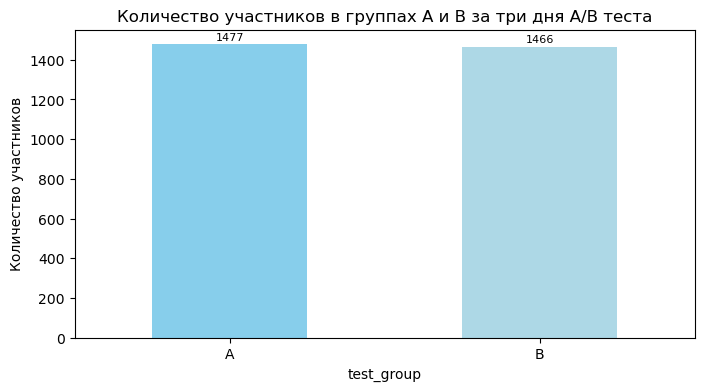

In [19]:
users_group=sessions_test_part.groupby('test_group')['user_id'].nunique()

#Построим график
colors=['skyblue', 'lightblue']
ax=users_group.plot(
    kind='bar',
    title='Количество участников в группах А и В за три дня A/B теста',
    figsize=(8, 4),
    rot=0,
    ylabel='Количество участников',
    color=colors
)

for i, v in enumerate(users_group):
    ax.text(i, v+10, str(v), ha='center', va='bottom', fontsize=8)

plt.show()

В контрольной группе A — 1477 пользователей, в тестовой B — 1466.

Процентная разница между группами составляет всего 0.74%, что существенно ниже допустимого порога(10–15%).

На основании данных за первые три дня A/B‑теста можно уверенно заключить: группы распределены корректно и сбалансированы по количеству участников.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [20]:
#Найдём пользователей, которые попали больше, чем в одну группу
double_users=sessions_test_part.groupby('user_id').agg({'test_group': 'nunique'}).query('test_group > 1')

double_users

,test_group
user_id,


То есть делаем вывод, что таких пользоватей нет. Каждый учатсник находится строго в одной группе.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построем диаграмму по долям каждого типа устройств для участников групп A и B.

In [21]:
#Считаем количество пользователей по группам и устройствам
users_device=sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'users_count'})

In [22]:
#Общее количество пользователей в каждой группе
users_device['total_in_group']=users_device.groupby('test_group')['users_count'].transform('sum')

In [23]:
#Доля каждого типа устройства в группе
users_device['share']=users_device['users_count']/users_device['total_in_group']

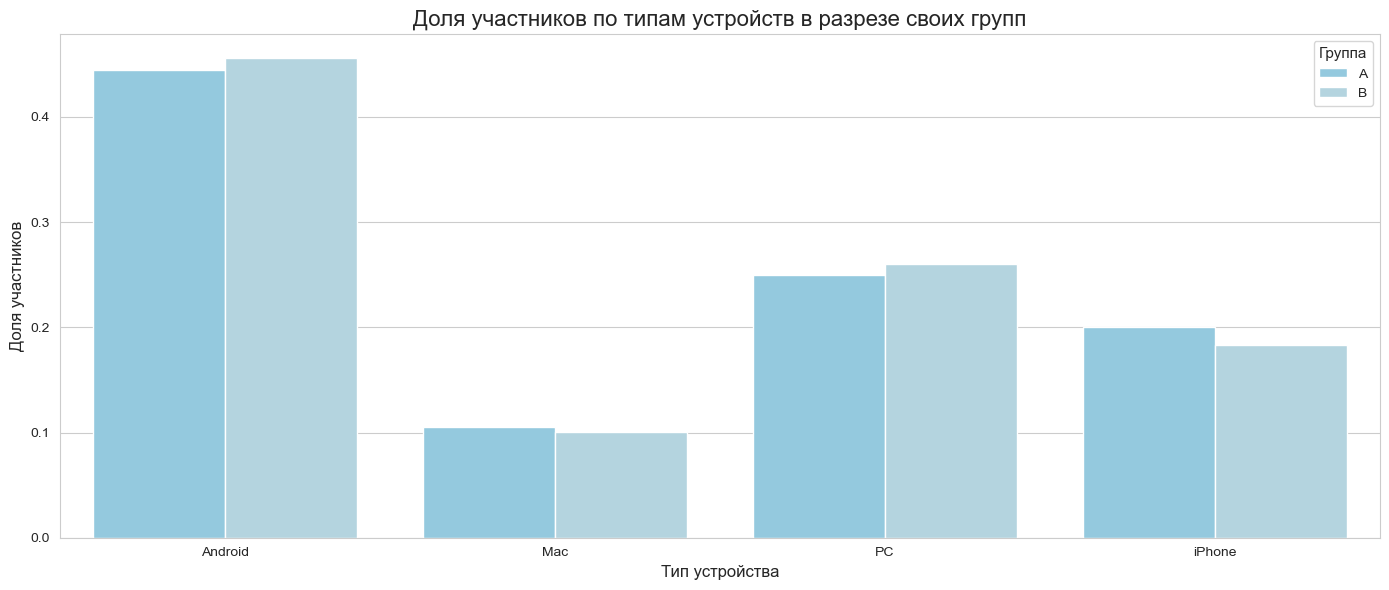

In [24]:
#Построим график
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

colors = ['skyblue', 'lightblue']

ax = sns.barplot(
    data=users_device,
    x='device',                
    y='share',                 
    hue='test_group',          
    palette=colors             
)

plt.title('Доля участников по типам устройств в разрезе своих групп', fontsize=16)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля участников', fontsize=12)

#for container in ax.containers:
#    ax.bar_label(container, labels=[f'{val:.1%}' for val in container.datavalues], padding=3)

plt.legend(title='Группа', title_fontsize=11, fontsize=10, loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Количество пользователей в группах практически одинаково, распределение по типам устройств практически идентично (максимальная разница — 1.7% по iPhone).
Рандомизация прошла успешно — группы A и B сбалансированы.

#### 3.4. Равномерность распределения пользователей по регионам
Убедимся, что пользователи равномерно распределены по регионам.

Построем диаграмму по долям каждого региона для участников групп A и B.

In [25]:
#Считаем количество уникальных пользователей по группам и регионам
users_region=sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'users_count'})

In [26]:
#Общее количество пользователей в каждой группе
users_region['total_in_group']=users_region.groupby('test_group')['users_count'].transform('sum')

In [27]:
#Доля каждого региона в группе
users_region['share']=users_region['users_count']/users_region['total_in_group']

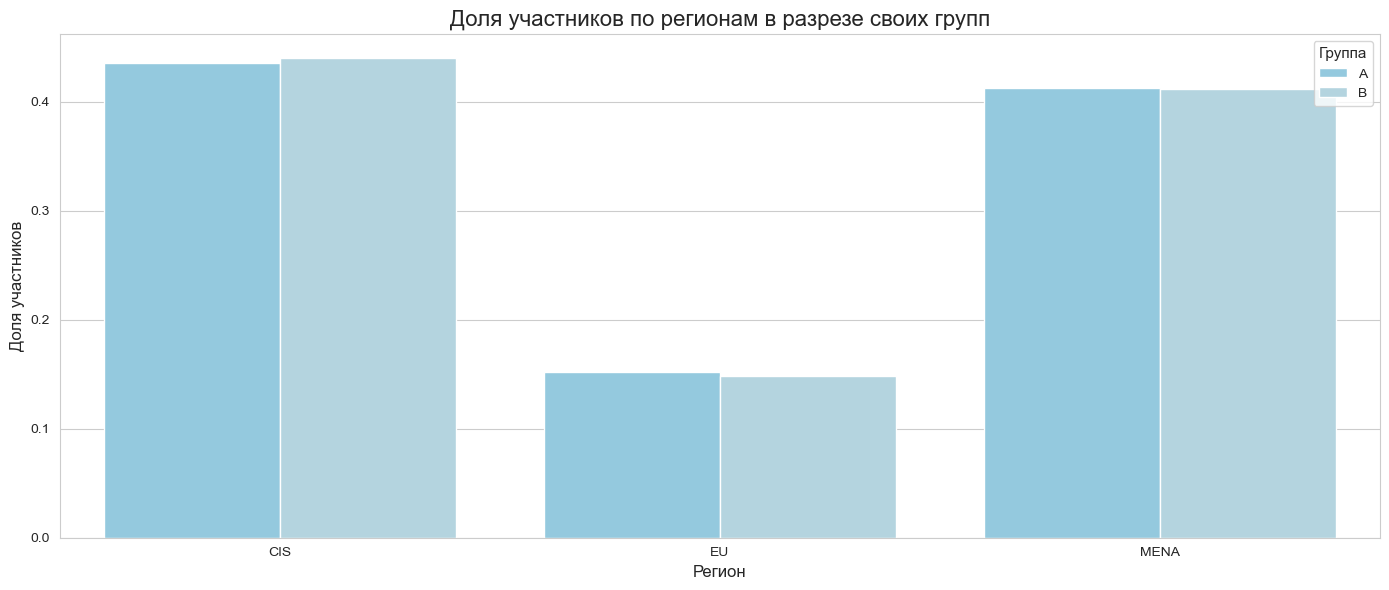

In [28]:
#Построим график
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

colors = ['skyblue', 'lightblue']

ax = sns.barplot(
    data=users_region,
    x='region',                
    y='share',                 
    hue='test_group',          
    palette=colors             
)

plt.title('Доля участников по регионам в разрезе своих групп', fontsize=16)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Доля участников', fontsize=12)

#for container in ax.containers:
#    ax.bar_label(container, labels=[f'{val:.1%}' for val in container.datavalues], padding=3)

plt.legend(title='Группа', title_fontsize=11, fontsize=10, loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Региональный состав сбалансирован, максимальная разница по регионам — всего 0.4% (для CIS и EU).

#### 3.5. Вывод после проверки A/B-теста
Различие в количестве участников в группах:
- группа A - 1477 пользователей;
- группа B - 1466 пользователей;
- процентная разница - 0.74%.

<b>Вывод:</b> различие незначительное (существенно ниже порога 10–15 %), группы сбалансированы по размеру.

Независимость выборок и пересечение пользователей:
- количество пользователей, попавших в обе группы - 0.

<b>Вывод:</b> выборки полностью независимы, пересечений нет. Условие корректности A/B‑теста выполнено.

Равномерность распределения по категориальным переменным:
- по устройствам - максимальная разница по категориям (Android, PC, iPhone, Mac) - 1.7% (по iPhone).

<b>Вывод:</b> распределение практически идентичное, различия минимальны.

- по регионам - максимальная разница по категориям (CIS, MENA, EU) - 0.4%.

<b>Вывод:</b> распределение идентичное, значимые расхождения отсутствуют.

Общее заключение о корректности теста:
- группы сбалансированы по размеру;
- выборы независимы (нет пересечений);
- паспределение по устройствам и регионам равномерное.

<b>Промежуточный вывод:</b> A/B‑тест проходит корректно, без нарушений. Нет признаков дисбаланса, загрязнения данных или проблем с рандомизацией. Результаты теста можно считать достоверными.

### 4. Проверка результатов A/B-теста
Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики
Считаем и сохраняем в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

В датафрейме `sessions_test` создаём дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [29]:
#Сохраняем датафрейм sessions_test
sessions_test=pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [30]:
#Cоздаём дополнительный столбец good_session
sessions_test['good_session']=(sessions_test['page_counter']>=4).astype(int)

sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

<b>Формулировка гипотез (для ключевой метрики):</b>
- целевая метрика - доля первых сессий с ≥ 4 просмотренными страницами (`good_session`).
- H₀ (нулевая гипотеза): новый алгоритм не приводит к изменению количества успешных сессий (сессий >4 страниц):
μ<sub><em>test</em></sub>=μ<sub><em>control</em></sub> (где μ<sub><em>test</em></sub> — доля `good_session` в тестовой группе, μ<sub><em>control</em></sub> — в контрольной);
- H₁ (альтернативная гипотеза): Новый алгоритм увеличивает среднее количество успешных сессий (сессий >4 страниц):
μ<sub><em>test</em></sub>>μ<sub><em>control</em></sub>.

Это отмечено в пункте `2. Подготовка к тесту`.

<b>Прокси-метрики:</b>
- среднее число страниц в первой сессии;
- и соответственно доля первых сессий с 3 и более страницами.

Эти метрики могут указывать на увлечённость пользователя.

<b>Барьерные метрики:</b>
- время загрузки страницы (не добавит ли новый алгоритм рекомендаций время загрузки страниц);
- ошибки при загрузке страницы;
- количество пользоватей с платной подпиской (снижение числа участников с платной версией будет говорить об обратном эффекте).

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [31]:
#Оставляем только первые сессии каждого пользователя
first_sessions=sessions_test[sessions_test['session_number']==1].copy()
metrics=first_sessions.groupby('test_group').agg(first_sessions_user=('user_id', 'count'),good_first_sessions=('good_session', 'sum')).reset_index()
metrics['success_rate']=metrics['good_first_sessions']/metrics['first_sessions_user']

metrics[['test_group', 'first_sessions_user', 'good_first_sessions', 'success_rate']]

,test_group,first_sessions_user,good_first_sessions,success_rate
0,A,15162,4787,0.315724
1,B,15416,4851,0.314673


In [32]:
# Рассчитываем разницу в долях (A-B)
success_rate_A=metrics[metrics['test_group']=='A']['success_rate'].values[0]
success_rate_B=metrics[metrics['test_group']=='B']['success_rate'].values[0]

diff_success_rate_b_a=success_rate_B-success_rate_A
print(f'Разница: {diff_success_rate_b_a:}')

Разница: -0.0010504523811919464


Разница долей успешных сессий в обеих группах практически не отличается. То есть тест показывает, что новый алгоритм не увеличил долю успешных первых сессий. Количество успешных сессий в тестовой выборке примерно на 0.11% ниже, чем в контрольной, но делать выводы только на основе этого значения будет некорректно.

#### 4.4. Насколько статистически значимо изменение ключевой метрики
Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

Выведем на экран полученное значение p-value, сделаем свои выводы о статистической значимости. Уровень значимости в эксперименте был выбран на уровне 0.05.

In [33]:
#Считаем ОТДЕЛЬНО для каждой группы n-общее количество первых сессий, m-good_session, p-доля для проведения дальнейшего теста
n_a=metrics[metrics['test_group']=='A']['first_sessions_user'].values[0]
n_b=metrics[metrics['test_group']=='B']['first_sessions_user'].values[0]

m_a=metrics[metrics['test_group']=='A']['good_first_sessions'].values[0]
m_b=metrics[metrics['test_group']=='B']['good_first_sessions'].values[0]

p_a=m_a/n_a
p_b=m_b/n_b

print(f'В группе A {m_a} успешных сессий из {n_a} сессий и доля {p_a:.4f}')
print(f'В группе B {m_b} успешных сессий из {n_b} сессий и доля {p_b:.4f}')

В группе A 4787 успешных сессий из 15162 сессий и доля 0.3157
В группе B 4851 успешных сессий из 15416 сессий и доля 0.3147


In [34]:
# Проверка предпосылки для Z-теста (np>10 и n(1-p)>10)
if (n_a*p_a>10) and (n_a*(1-p_a)>10) and (n_b*p_b>10) and (n_b*(1-p_b)>10):
    print("Предпосылка для Z-теста выполняется.")
else:
    print("Предпосылка для Z-теста НЕ выполняется — результаты могут быть неточными.")

alpha=0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger'
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest:.5f}>{alpha}')
    print('Наблюдаемое изменение в метрики долей НЕ является статистически значимым')
else:
    print(f'pvalue={p_value_ztest:.5f}<{alpha}')
    print('Наблюдаемое изменение в метрики долей является статистически значимым')

Предпосылка для Z-теста выполняется.
pvalue=0.57835>0.05
Наблюдаемое изменение в метрики долей НЕ является статистически значимым


Эксперимент не выявил улучшений.

#### 4.5. Вывод по результатам A/B-эксперимента
<b>1. Характеристики проведённого эксперимента</b>

Целевая метрика: доля успешных первых сессий (просмотр ≥4 страниц при `session_number`=1).

Группы:
- A (контрольная) — старый алгоритм рекомендаций;
- B (тестовая) — новый алгоритм рекомендаций.

Количество пользователей: всего ~30579 уникальных пользователей.

Объём данных по первым сессиям:
- группа A: 15162 сессии;
- группа B: 15416 сессий.

Расчётная длительность: 9 дней (при ежедневном трафике ~9 907 DAU и требуемом размере выборки 41 041 на группу).

<b>2. Влияние нового алгоритма на ключевую метрику</b>

Новый алгоритм не привёл к росту доли успешных первых сессий. Наблюдается незначительное снижение:

- группа A (старый алгоритм): 31.57% (4787 из 15162);
- группа B (новый алгоритм): 31.47% (4851 из 15416);
- разница (A-B): 0.11%

Изменение минимально и находится в пределах статистического шума.

<b>3. Значение p‑value и статистическая значимость</b>

p‑value Z‑теста пропорций (односторонний, H₁: p_B > p_A): 0.578352.

Поскольку p‑value >0.05, нулевая гипотеза не отвергается. Эффект статистически не значим.

<b>4. Рекомендация по внедрению нововведения</b>
   
Не внедрять новый алгоритм в продуктивную среду.

Обоснование:
- отсутствие статистически значимого улучшения (p = 0.578);
- нулевая практическая ценность изменения (−0.11%);
- не достигнуто целевое повышение вовлечённости в первой сессии.

<b>Рекомендации для дальнейших действий</b>

- проанализировать логи рекомендаций: проверить качество стартового контента, уровень персонализации для новых пользователей, скорость загрузки рекомендаций;
- тестировать более выраженные изменения: задать MDE на уровне 5–10% для повышения шансов обнаружить эффект;
- увеличить мощность теста в будущих экспериментах.

<b>Итог:</b>
Новый алгоритм рекомендаций не подтвердил свою эффективность на ключевой метрике вовлечённости. Текущая версия не готова к внедрению. Рекомендуется доработать гипотезу и провести повторный тест с иными параметрами или метриками.